In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# pip install pyarrow and dask
import dask.dataframe as dd
import os

In [2]:
# Changing directory
os.chdir('C:/Users/edwin/OneDrive/Documents/GitHub/CHC')

# Importing the data
region = ['eastern_east_africa', 'eastern_ukraine', 'lake_victoria_basin', 'south_sudan', 'southern_africa', 'sri_lanka', 'west_africa']
model = ['CanESM5', 'CCSM4', 'CESM1', 'GEM5', 'GFDL', 'NASA', 'NCEP']
for i in region:
    for j in model:
        globals()['{}_{}'.format(i, j)] = dd.read_csv('data/csv/csv_merged_data/{}_{}_merged.csv'.format(i, j))

In [17]:
# Spatial means precip and predicted precip of each region, grouped by time and lead time
eastern_east_africa = eastern_east_africa_CanESM5.drop(['date of prediction', 'realization time', 'month', 'year'], axis = 1).groupby(['time', 'lead time'])[['predicted precip', 'precip']].mean().compute().reset_index()
for i in region:
    for j in model:
        # Calculate the spatial means for each region and model
        globals()['{}_{}_spatial_means'.format(i, j)] = (globals()['{}_{}'.format(i, j)]
                                                         .drop(['date of prediction', 'realization time', 'year'], axis = 1)
                                                         .groupby(['time', 'month', 'lead time'])[['predicted precip', 'precip']]
                                                         .mean().compute().reset_index())
        # Calculate the correlation between predicted precip and precip means
        globals()['{}_{}_spatial_means_corr'.format(i, j)] = (globals()['{}_{}_spatial_means'.format(i, j)]
                                                              .groupby(['month', 'lead time'])[['predicted precip', 'precip']].corr(method = 'spearman')
                                                              .iloc[0::2, -1].droplevel(level = 2).reset_index())
        globals()['{}_{}_spatial_means_corr'.format(i, j)]['region'] = i
        globals()['{}_{}_spatial_means_corr'.format(i, j)]['model'] = j

In [ ]:
# Concatenate all the dataframes
spatial_means_corr = pd.concat([globals()['{}_{}_spatial_means_corr'.format(i, j)] for i in region for j in model], ignore_index = True)
spatial_means_corr = spatial_means_corr.rename(columns = {'precip': 'corr'})

,month,lead time,corr,region,model
0,1,0.5,0.472747,eastern_east_africa,CanESM5
1,1,1.5,0.490545,eastern_east_africa,CanESM5
2,1,2.5,0.078532,eastern_east_africa,CanESM5
3,1,3.5,0.329032,eastern_east_africa,CanESM5
4,1,4.5,0.108343,eastern_east_africa,CanESM5
...,...,...,...,...,...
6631,12,5.5,-0.087500,west_africa,NCEP
6632,12,6.5,0.037097,west_africa,NCEP
6633,12,7.5,0.155645,west_africa,NCEP
6634,12,8.5,0.287903,west_africa,NCEP


In [58]:
#heatmap 
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs, vmin=-1, vmax=1, 
                cmap=sns.color_palette('vlag', 12),
                linewidths=0.1, linecolor='black')
    plt.xticks(np.arange(0.5, 12.5, 1))  # Set xticks explicitly
    plt.gca().set_xticklabels(np.arange(0.5, 12.5, 1))  # Set xticklabels
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.gca().invert_yaxis()

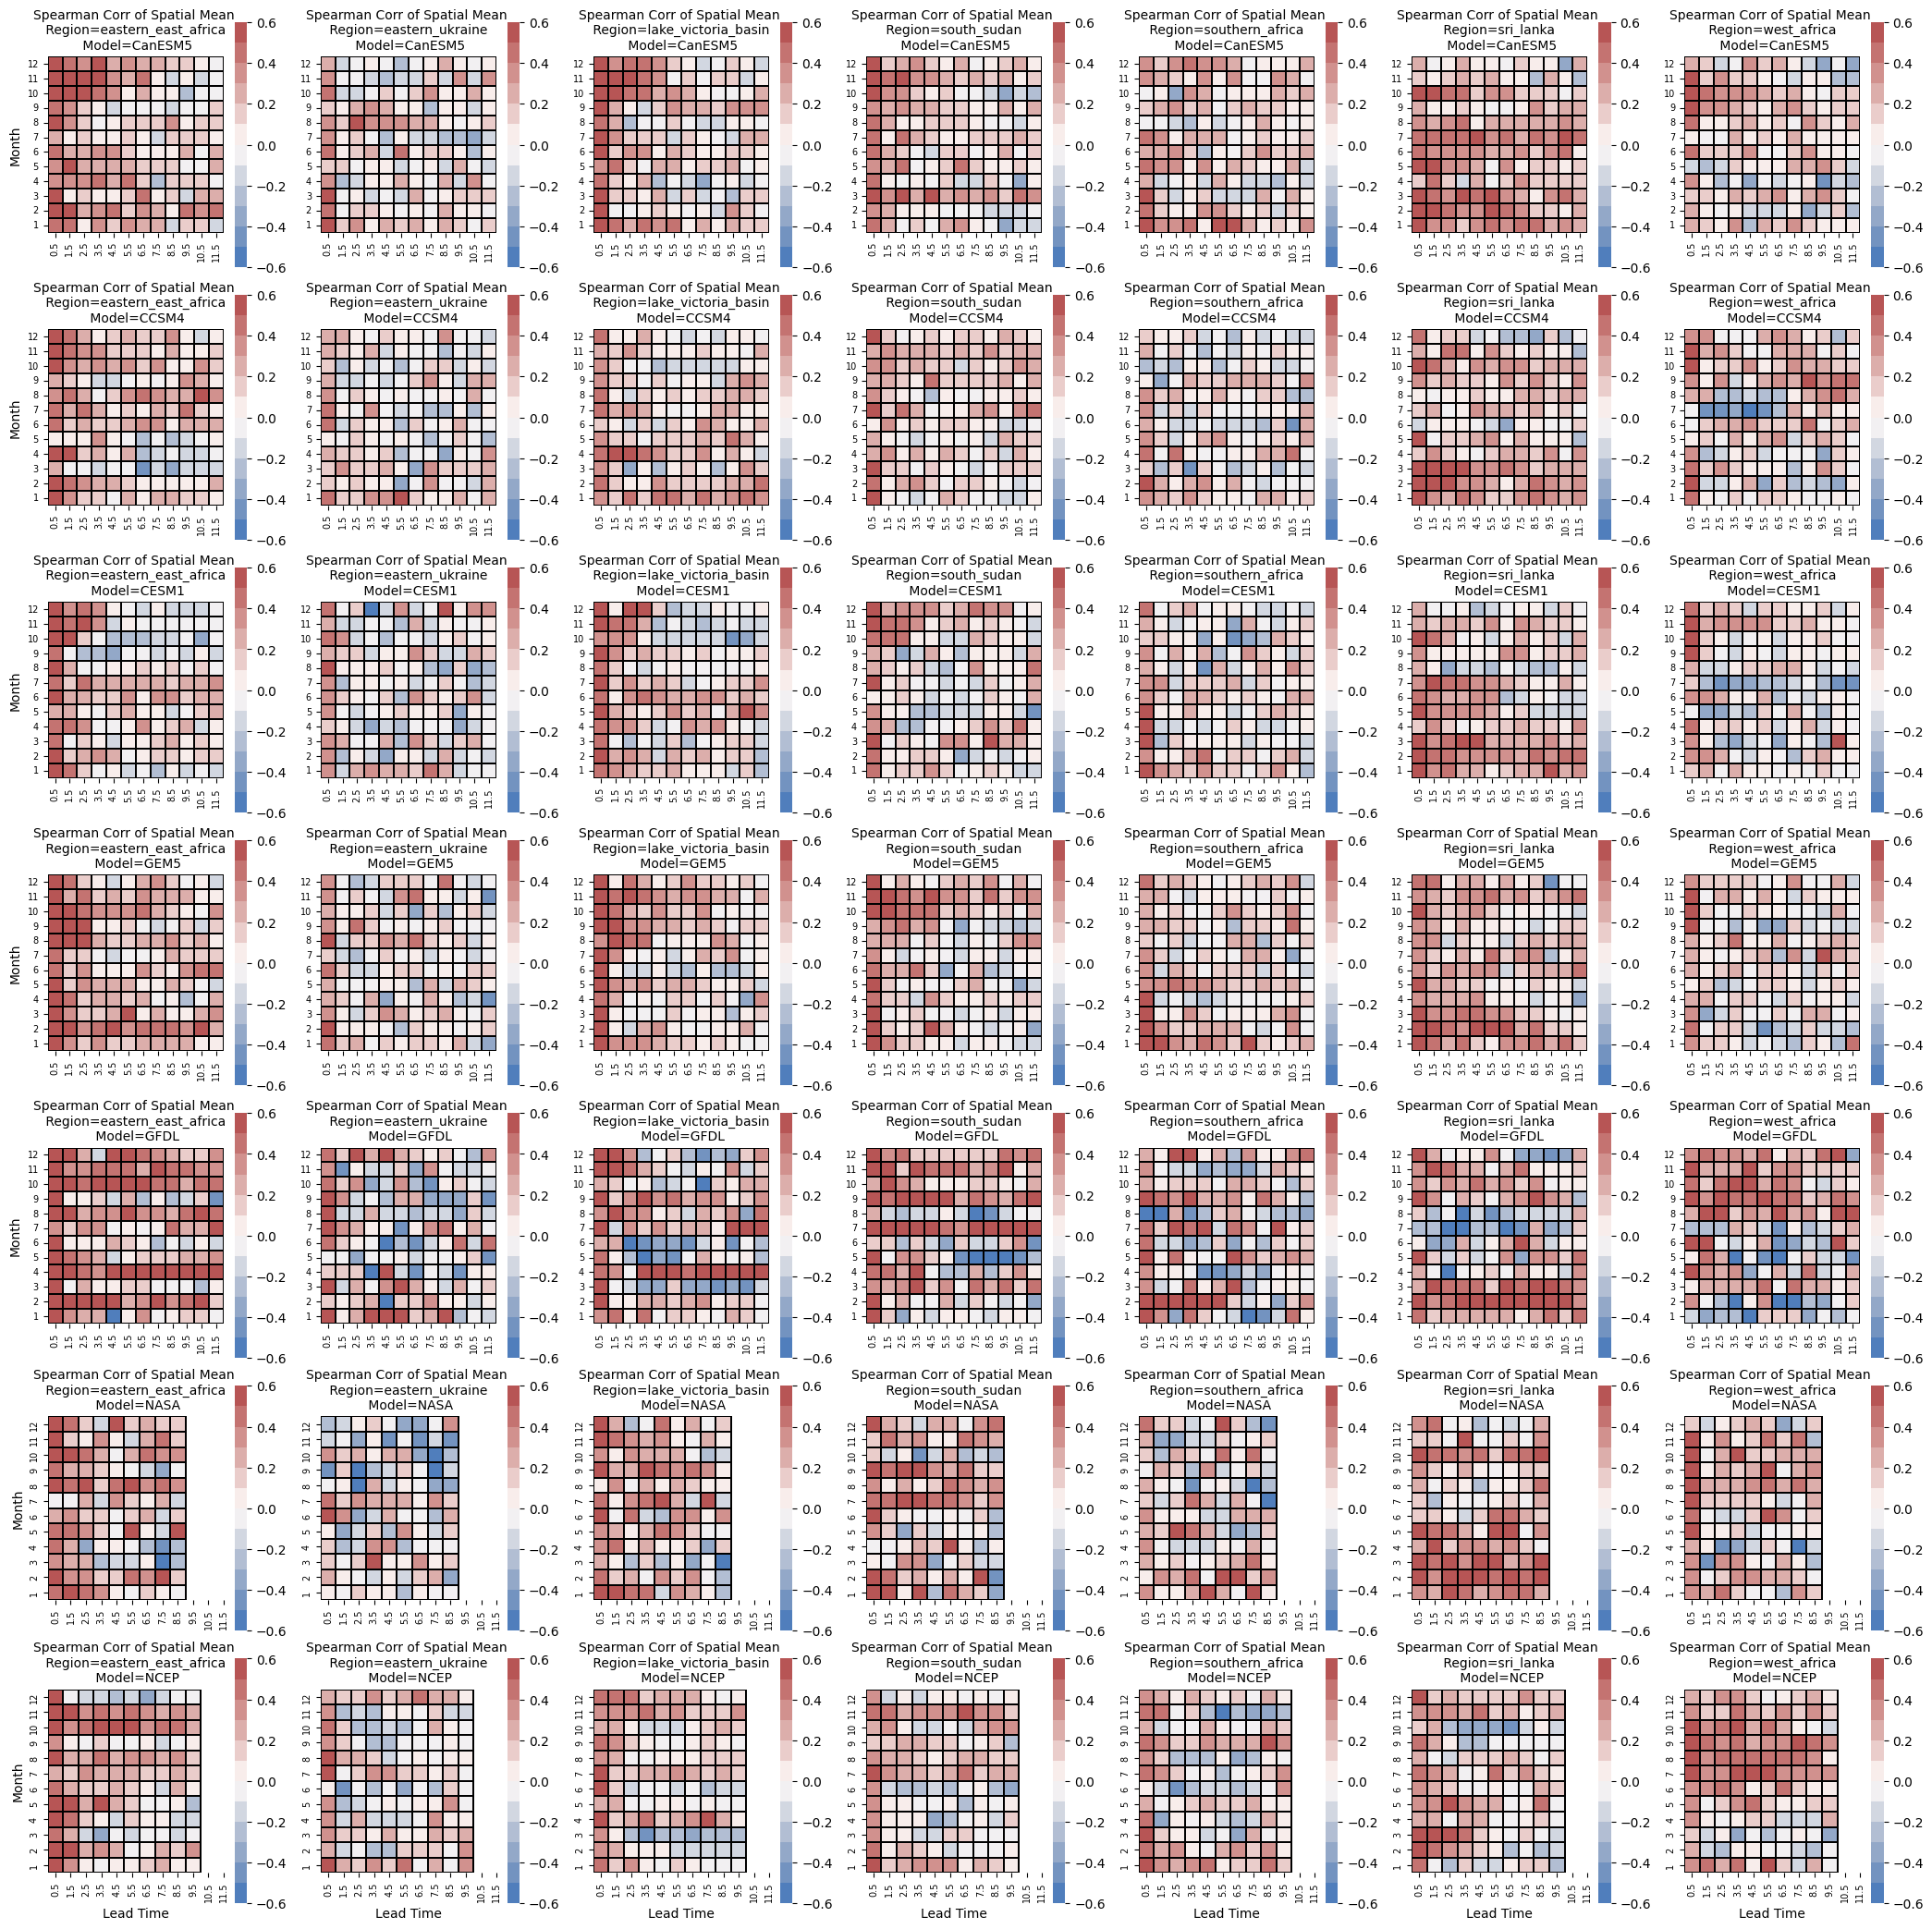

In [57]:
fg = sns.FacetGrid(spatial_means_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead time', 'month', 'corr', square = True)

fg.set_titles('Spearman Corr of Spatial Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/spatial_means_corr.png')

In [49]:
# Temporal means precip and predicted precip of each pixel, grouped by latitude, longitude, month and lead time
for i in region:
    for j in model:
        # Calculate the temporal means for each region and model
        globals()['{}_{}_temporal_means'.format(i, j)] = (globals()['{}_{}'.format(i, j)]
                                                         .drop(['date of prediction', 'realization time', 'year'], axis = 1)
                                                         .groupby(['latitude', 'longitude', 'month', 'lead time'])[['predicted precip', 'precip']]
                                                         .mean().compute().reset_index())
        # Calculate the correlation between predicted precip and precip temporal means
        globals()['{}_{}_temporal_means_corr'.format(i, j)] = (globals()['{}_{}_temporal_means'.format(i, j)].groupby(['month', 'lead time'])[['predicted precip', 'precip']]
                                                               .corr(method = 'spearman').iloc[0::2, -1].droplevel(level = 2).reset_index())
        globals()['{}_{}_temporal_means_corr'.format(i, j)]['region'] = i
        globals()['{}_{}_temporal_means_corr'.format(i, j)]['model'] = j

In [50]:
# Concatenate all the dataframes, renaming precip to corr
temporal_means_corr = pd.concat([globals()['{}_{}_temporal_means_corr'.format(i, j)] for i in region for j in model], ignore_index = True)
temporal_means_corr = temporal_means_corr.rename(columns = {'precip': 'corr'})

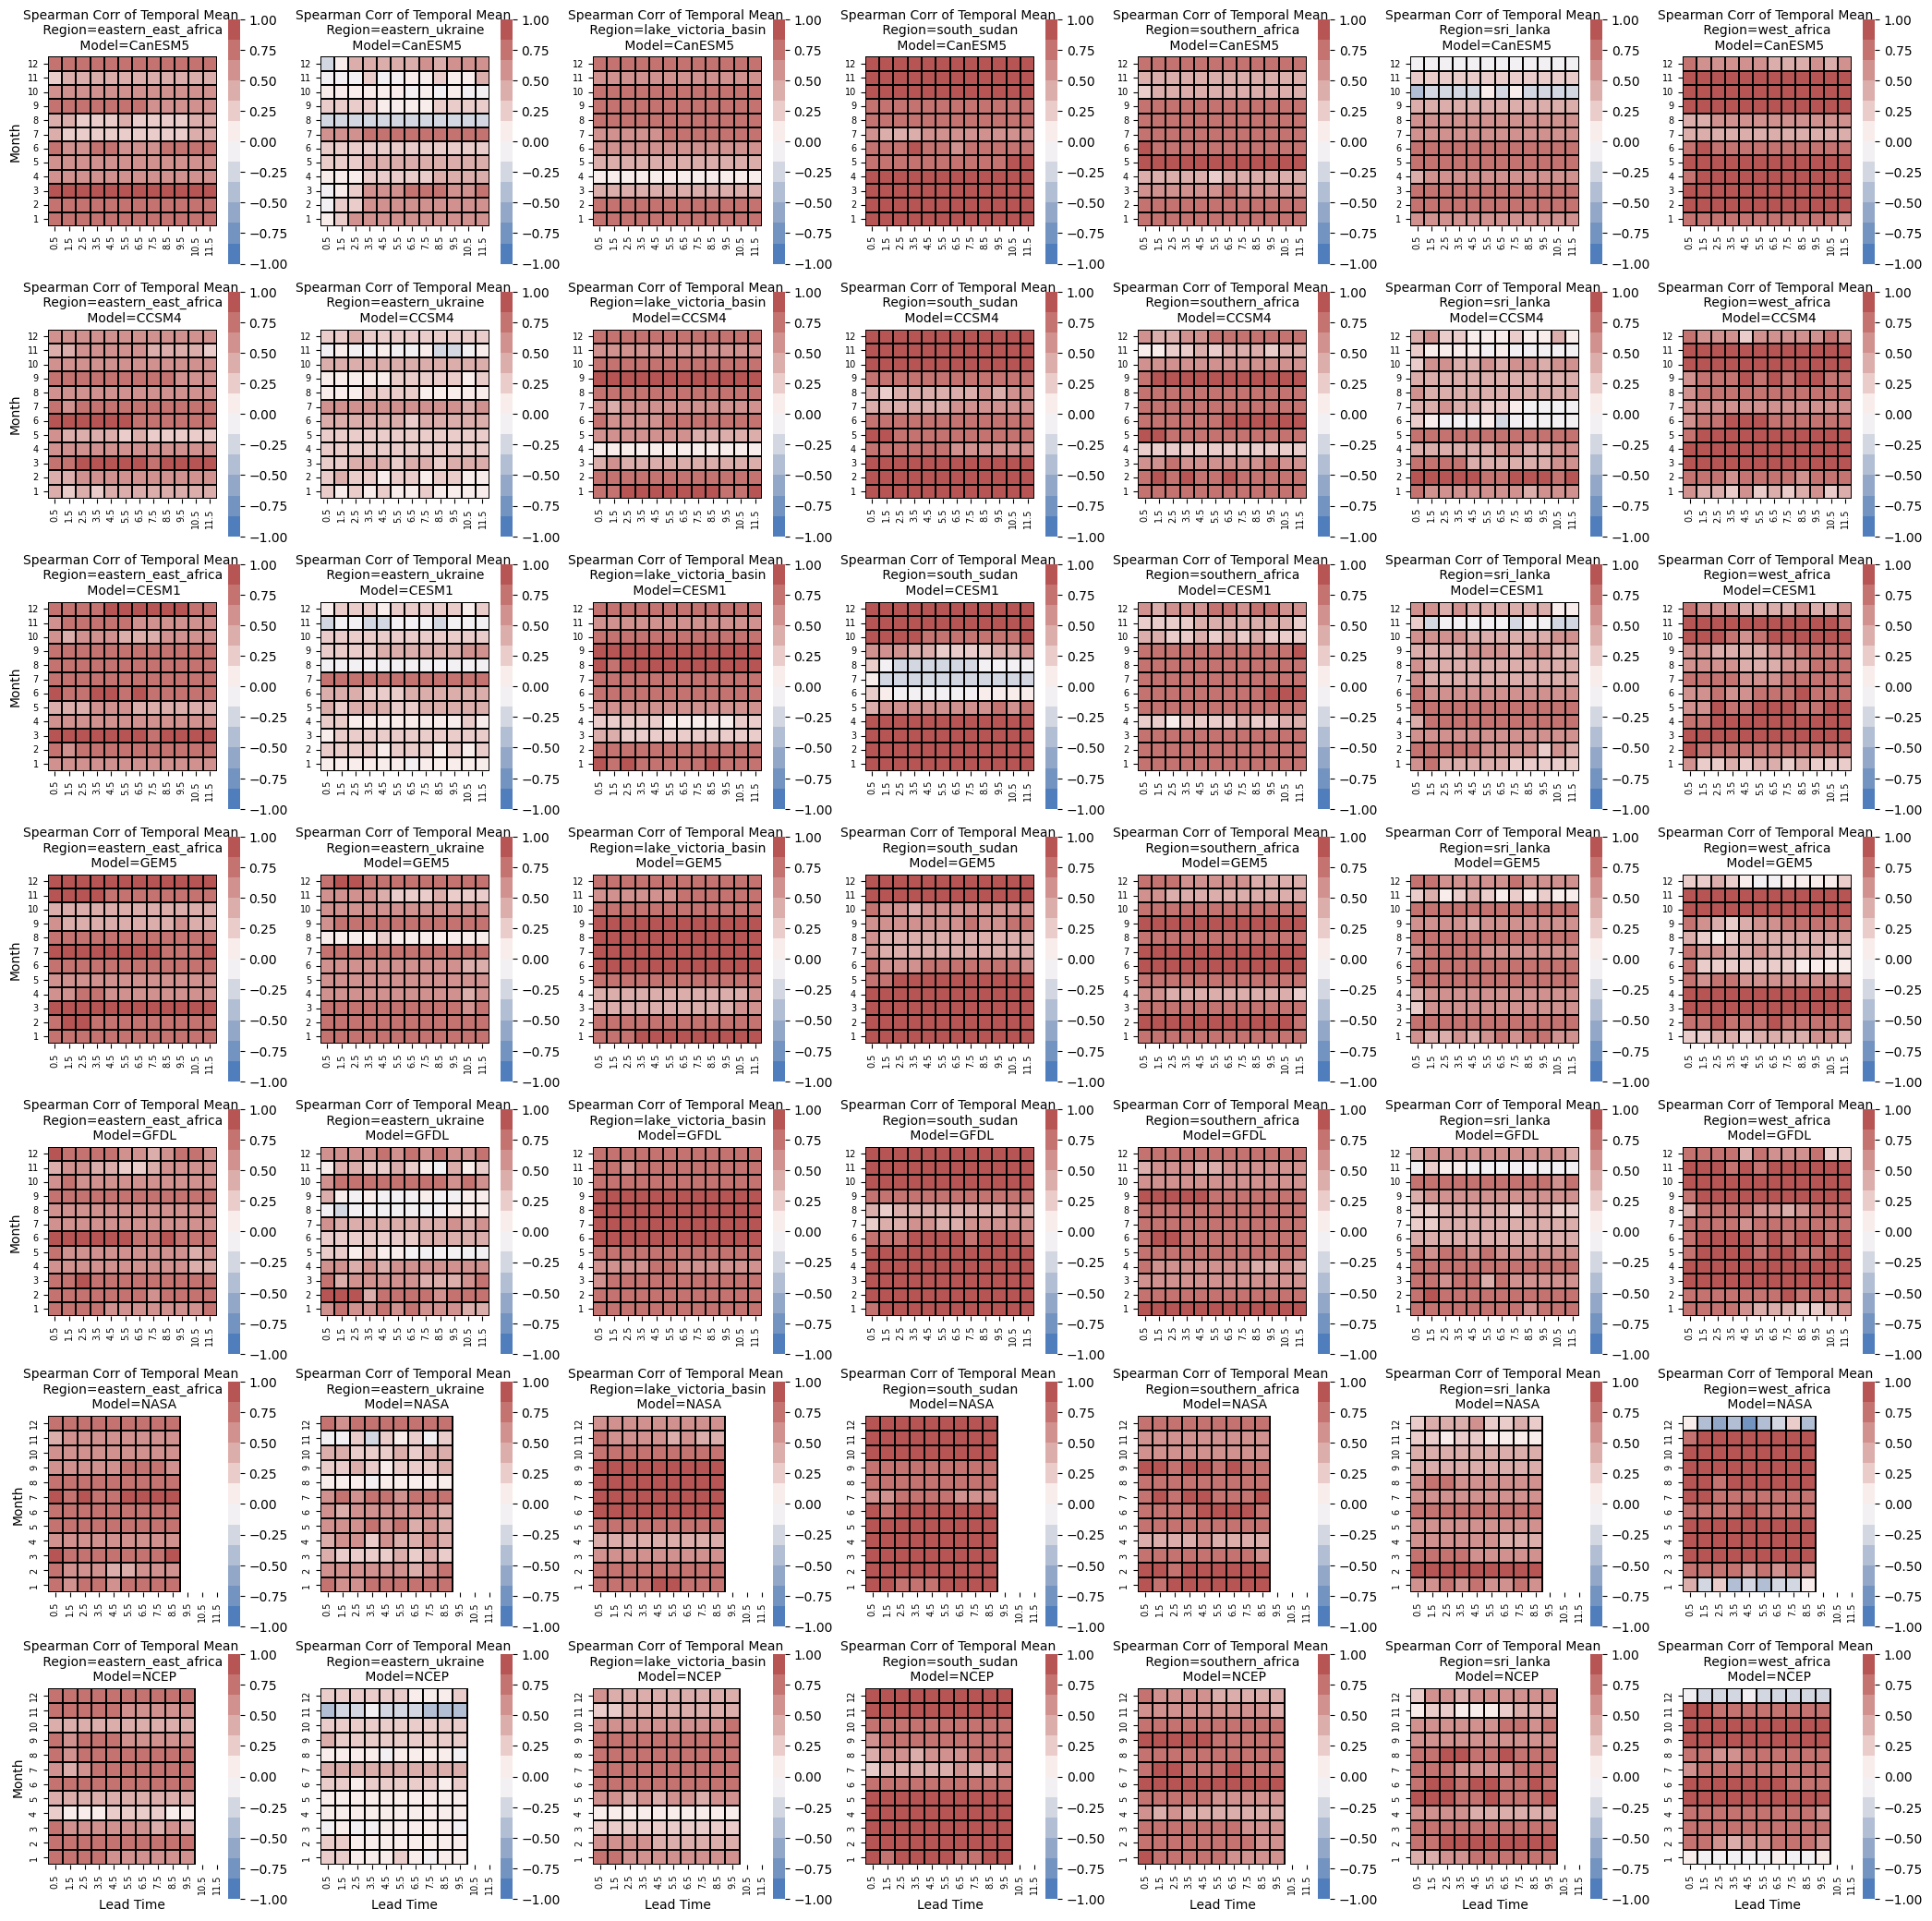

In [59]:
fg = sns.FacetGrid(temporal_means_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead time', 'month', 'corr', square = True)

fg.set_titles('Spearman Corr of Temporal Mean \n Region={col_name} \n Model={row_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/temporal_means_corr.png')

In [ ]:
# test
sri_lanka = sri_lanka_CanESM5.drop(['date of prediction', 'realization time', 'year'], axis = 1).groupby(['latitude', 'longitude', 'month', 'lead time'])[['predicted precip', 'precip']].mean().compute().reset_index()
sri_lanka_corr = sri_lanka.groupby(['month', 'lead time'])[['predicted precip', 'precip']].corr(method = 'spearman').iloc[0::2, -1].droplevel(level = 2).reset_index()
sri_lanka_corr['precip']

0      0.550387
1      0.540731
2      0.540731
3      0.540731
4      0.540731
         ...   
139   -0.064519
140   -0.064519
141   -0.064519
142   -0.064519
143   -0.064519
Name: precip, Length: 144, dtype: float64